In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
from google.colab import files

uploaded = files.upload()

Saving advertising.csv to advertising.csv


Load Dataset

In [4]:
df = pd.read_csv("advertising.csv")

check  dataset

In [5]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [7]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [9]:
df.shape

(200, 4)

In [10]:
df.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [11]:
df.duplicated().sum

<bound method Series.sum of 0      False
1      False
2      False
3      False
4      False
       ...  
195    False
196    False
197    False
198    False
199    False
Length: 200, dtype: bool>

Corelation Heatmap

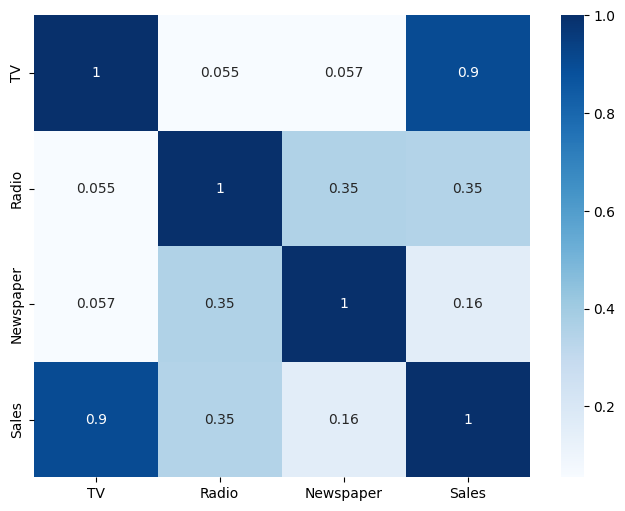

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),annot=True,cmap="Blues")
plt.show()

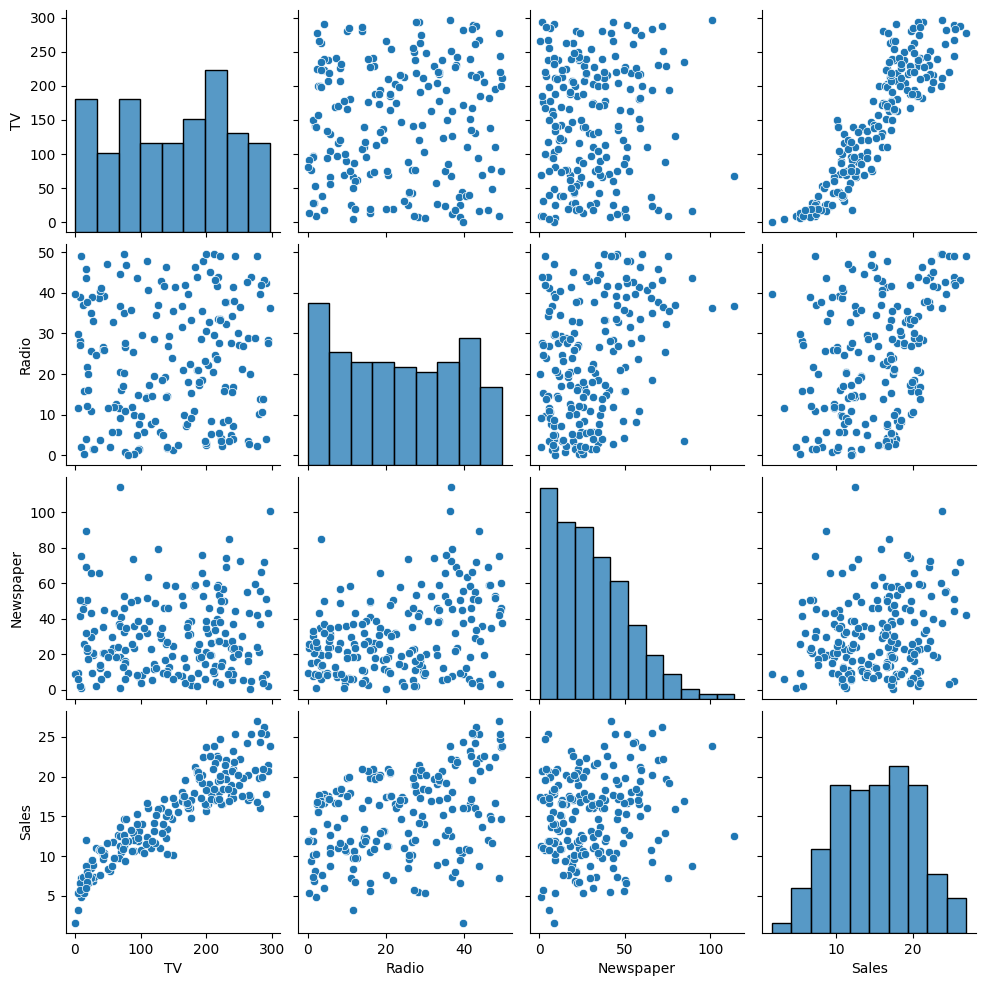

In [13]:
sns.pairplot(df)
plt.show()

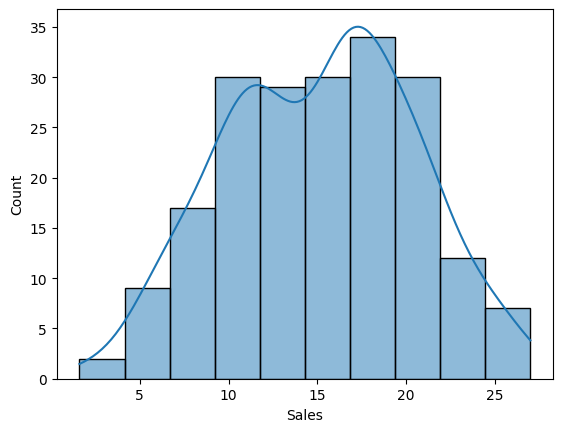

In [14]:
sns.histplot(df["Sales"],kde=True)
plt.show()

Feature Selection

In [15]:
X = df[['TV','Radio','Newspaper']]

In [16]:
y = df['Sales']

Train Test split

In [17]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Train Model

In [18]:
model=LinearRegression()

model.fit(X_train,y_train)

LinearRegression()

Prediction

In [19]:
y_pred=model.predict(X_test)

In [20]:
prediction=pd.DataFrame({
    "Actual":y_test,
    "Predicted":y_pred
})

prediction.head()

,Actual,Predicted
95,16.9,17.034772
15,22.4,20.409740
30,21.4,23.723989
158,7.3,9.272785
128,24.7,21.682719


 ** Evaluate Model**

MAE

In [21]:
mae=mean_absolute_error(y_test,y_pred)
print("MAE:",mae)

MAE: 1.2748262109549338


MSE

In [22]:
mse=mean_squared_error(y_test,y_pred)
print("MSE:",mse)

MSE: 2.9077569102710896


RMSE

In [23]:
rmse=np.sqrt(mse)
print("RMSE:",rmse)

RMSE: 1.7052146229349223


R2 Score

In [ ]:
r2=r2_score(y_test,y_pred)
print("R2 Score:",r2)

Actual Vs Predicted

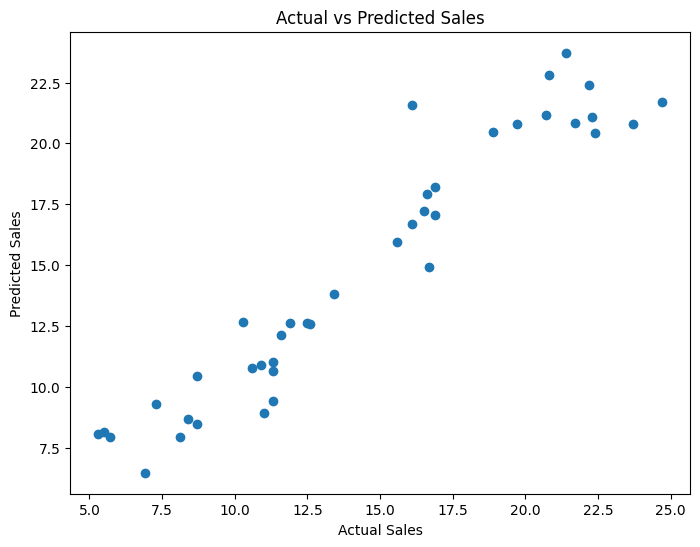

In [24]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

Residual Plot

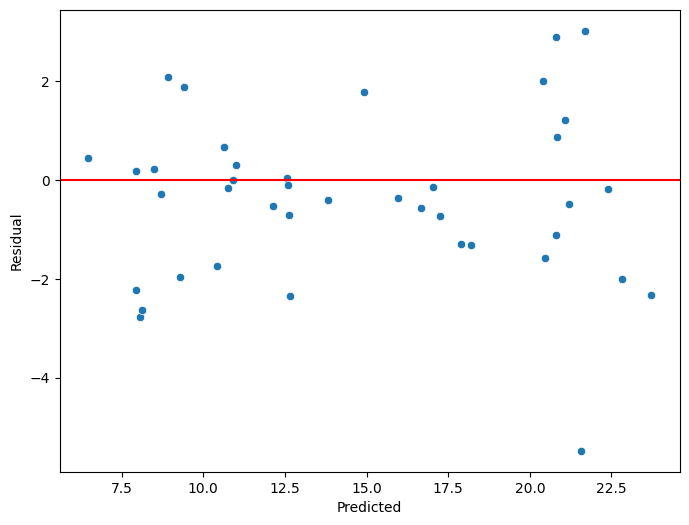

In [25]:
residuals=y_test-y_pred

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred,y=residuals)
plt.axhline(0,color='red')
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.show()

Predict New Score

In [26]:
new_data=pd.DataFrame({
    "TV":[150],
    "Radio":[25],
    "Newspaper":[30]
})

prediction=model.predict(new_data)

print("Predicted Sales:",prediction[0])

Predicted Sales: 15.544250492282009


**Feature Selection**

Linear Regression Coefficient

In [27]:
coef=pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":model.coef_
})

coef

,Feature,Coefficient
0,TV,0.054509
1,Radio,0.100945
2,Newspaper,0.004337


Bar Plot

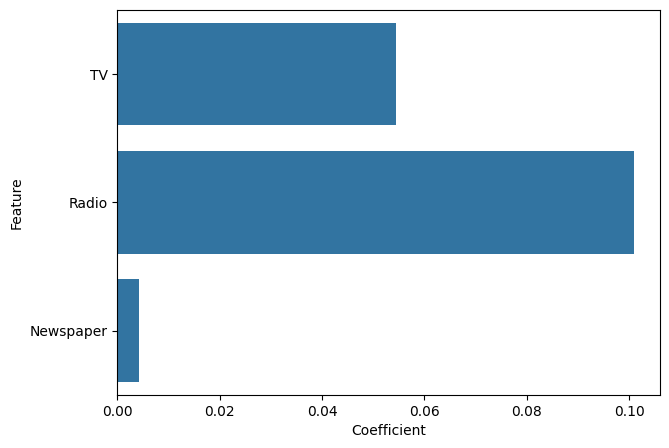

In [28]:
plt.figure(figsize=(7,5))
sns.barplot(x="Coefficient",y="Feature",data=coef)
plt.show()

Save Model

In [29]:
import joblib

joblib.dump(model,"sales_prediction_model.pkl")

['sales_prediction_model.pkl']

Load Model

In [30]:
loaded_model=joblib.load("sales_prediction_model.pkl")